The accumulation of aboveground biomass during the growing season typically follows a sigmoid (S-shaped) pattern. Early in the season plants are small and grow slowly, then growth accelerates and becomes nearly linear as the canopy closes and intercepts most of the incoming solar radiation, and finally growth slows down as the crop approaches maturity. The logistic model is one of the simplest and most widely used functions to describe this pattern.

In this exercise we will fit the logistic model to aboveground dry biomass observations of winter wheat and then use the fitted parameters to compute metrics with agronomic meaning, such as the maximum crop growth rate and the duration of the linear growth phase.

## Logistic model

$$ B = \frac{B_{max}}{1 + e^{-k(t-t_m)}}$$

$B$ is the aboveground dry biomass (Mg/ha)<br>
$B_{max}$ is the maximum aboveground dry biomass (Mg/ha)<br>
$t$ is the time in days after planting (DAP)<br>
$t_m$ is the inflection point, the time at which the growth rate reaches its maximum value (days)<br>
$k$ is a constant that determines the steepness of the curve (1/day)<br>

In [1]:
# Import modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


## Data

The dataset contains aboveground dry biomass of winter wheat grown under nonlimiting conditions at Chickasha, OK during the 2012/2013 growing season. Biomass was sampled at 11 dates in four replications. The values were obtained from Figure 2C in Lollato and Edwards (2015). The first row of the file contains the source of the data and the third row contains the units, so we will skip both rows.

In [2]:
# Read dataset
df = pd.read_csv('../datasets/wheat_biomass_chickasha_ok_2012_2013.csv', skiprows=[0,2])
df['date'] = pd.to_datetime(df['date'], format='%m/%d/%Y')
df.head()


,date,dap,biomass_rep_1,biomass_rep_2,biomass_rep_3,biomass_rep_4
0,2012-10-30,12,0.03,0.02,0.02,0.02
1,2012-11-20,33,0.37,0.27,0.39,0.42
2,2012-12-16,59,1.79,1.74,2.20,1.51
3,2013-01-26,100,2.94,2.34,2.49,2.86
4,2013-02-18,123,3.06,3.37,2.62,3.24


In [3]:
# Compute average biomass across replications
df['biomass_avg'] = df[['biomass_rep_1','biomass_rep_2','biomass_rep_3','biomass_rep_4']].mean(axis=1)

# Store days after planting and average biomass as NumPy arrays
dap = df['dap'].values
biomass = df['biomass_avg'].values


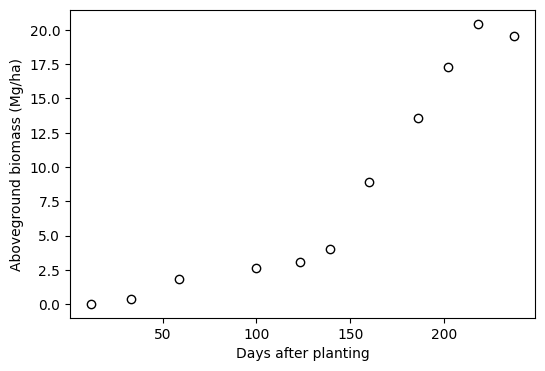

In [4]:
# Plot observations
plt.figure(figsize=(6,4))
plt.scatter(dap, biomass, facecolor='w', edgecolor='k')
plt.xlabel('Days after planting')
plt.ylabel('Aboveground biomass (Mg/ha)')
plt.show()


Notice that biomass barely changes between about 100 and 140 days after planting. This period corresponds to winter dormancy (late January to early March), when low temperatures limit wheat growth. The logistic model does not explicitly account for dormancy, so we should keep this in mind when interpreting the fitted curve.

## Fit model

In [5]:
# Define logistic model
logistic = lambda t,B_max,t_m,k: B_max / (1 + np.exp(-k*(t - t_m)))


In [6]:
# Fit model to observations
p0 = [20, 175, 0.05] # Initial guess for B_max, t_m, and k based on the figure
par, cov = curve_fit(logistic, dap, biomass, p0=p0)
B_max, t_m, k = par

print(f'B_max = {B_max:.1f} Mg/ha')
print(f't_m = {t_m:.0f} days')
print(f'k = {k:.4f} 1/day')


B_max = 22.5 Mg/ha
t_m = 172 days
k = 0.0377 1/day


In [7]:
# Compute root mean squared error
biomass_pred = logistic(dap, *par)
rmse = np.sqrt(np.mean((biomass_pred - biomass)**2))
print(f'RMSE = {rmse:.2f} Mg/ha')


RMSE = 0.88 Mg/ha


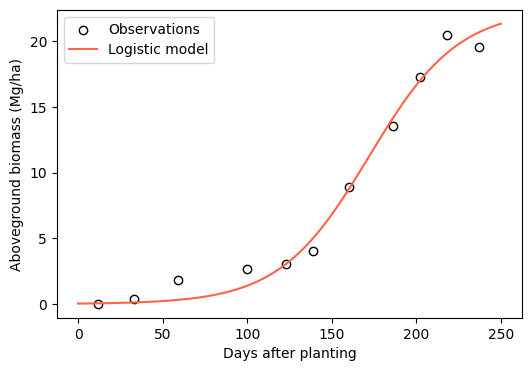

In [8]:
# Plot fitted model
dap_curve = np.arange(0, 251)
biomass_curve = logistic(dap_curve, *par)

plt.figure(figsize=(6,4))
plt.scatter(dap, biomass, facecolor='w', edgecolor='k', label='Observations')
plt.plot(dap_curve, biomass_curve, color='tomato', label='Logistic model')
plt.xlabel('Days after planting')
plt.ylabel('Aboveground biomass (Mg/ha)')
plt.legend()
plt.show()


## Crop growth rate

The crop growth rate is the first derivative of the biomass curve. For the logistic model the derivative has a simple form:

$$ \frac{dB}{dt} = k \ B \ \Big(1 - \frac{B}{B_{max}}\Big)$$

The growth rate reaches its maximum value of $k B_{max} / 4$ at $t = t_m$, which is exactly the point where the biomass is half of $B_{max}$.

In [9]:
# Compute crop growth rate (kg/ha/day)
growth_rate = k * biomass_curve * (1 - biomass_curve/B_max) * 1000 # Convert Mg to kg

max_growth_rate = k * B_max / 4 * 1000
print(f'Maximum growth rate of {max_growth_rate:.0f} kg/ha/day at {t_m:.0f} days after planting')


Maximum growth rate of 212 kg/ha/day at 172 days after planting


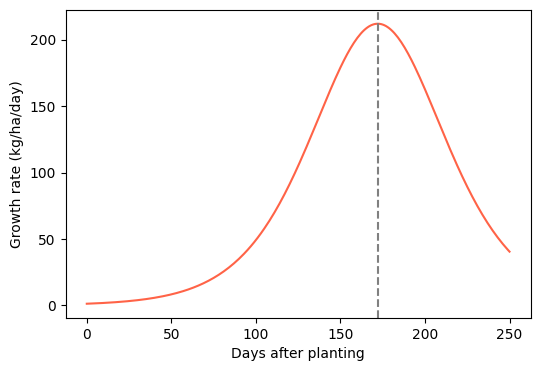

In [10]:
# Plot crop growth rate
plt.figure(figsize=(6,4))
plt.plot(dap_curve, growth_rate, color='tomato')
plt.axvline(t_m, linestyle='--', color='gray')
plt.xlabel('Days after planting')
plt.ylabel('Growth rate (kg/ha/day)')
plt.show()


## Linear growth phase

The growth rate increases rapidly before $t_m$ and decreases rapidly after $t_m$. The times at which these changes are fastest (the maximum and minimum of the second derivative) are an objective way of delimiting the period of nearly linear growth. For the logistic model these two points occur at:

$$ t = t_m \pm \frac{\ln(2 + \sqrt{3})}{k} \approx t_m \pm \frac{1.317}{k}$$

In [11]:
# Start and end of the linear growth phase
t_start = t_m - np.log(2 + np.sqrt(3)) / k
t_end = t_m + np.log(2 + np.sqrt(3)) / k

# Convert days after planting into calendar dates
planting_date = pd.Timestamp('2012-10-18')
date_start = planting_date + pd.Timedelta(days=round(t_start))
date_end = planting_date + pd.Timedelta(days=round(t_end))

print(f'Linear growth phase from {t_start:.0f} to {t_end:.0f} days after planting ({t_end-t_start:.0f} days)')
print(f'Linear growth phase from {date_start:%d-%b-%Y} to {date_end:%d-%b-%Y}')


Linear growth phase from 137 to 207 days after planting (70 days)
Linear growth phase from 04-Mar-2013 to 13-May-2013


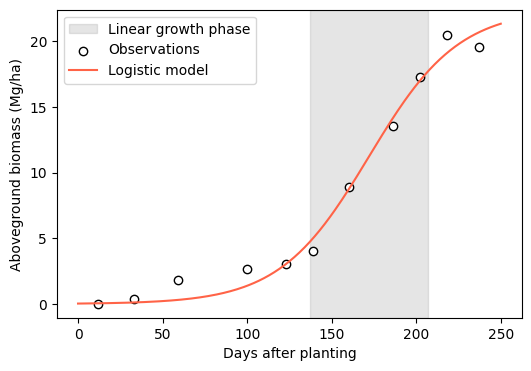

In [12]:
# Plot model with linear growth phase
plt.figure(figsize=(6,4))
plt.axvspan(t_start, t_end, color='gray', alpha=0.2, label='Linear growth phase')
plt.scatter(dap, biomass, facecolor='w', edgecolor='k', label='Observations')
plt.plot(dap_curve, biomass_curve, color='tomato', label='Logistic model')
plt.xlabel('Days after planting')
plt.ylabel('Aboveground biomass (Mg/ha)')
plt.legend()
plt.show()


## Time to reach a fraction of the maximum biomass

We can also rearrange the logistic model to find the time at which the crop reaches a given fraction $F$ of the maximum biomass (e.g., $F=0.9$ for 90% of $B_{max}$):

$$ t = t_m - \frac{1}{k} \ln \Big(\frac{1}{F} - 1\Big)$$

In [13]:
# Days to reach 50% and 90% of the maximum biomass
for F in [0.5, 0.9]:
    t_F = t_m - np.log(1/F - 1) / k
    date_F = planting_date + pd.Timedelta(days=round(t_F))
    print(f'{F*100:.0f}% of maximum biomass at {t_F:.0f} days after planting ({date_F:%d-%b-%Y})')


50% of maximum biomass at 172 days after planting (08-Apr-2013)
90% of maximum biomass at 230 days after planting (05-Jun-2013)


## Practice

- Fit the model to each replication separately. How much do the parameters $B_{max}$, $t_m$, and $k$ vary among replications?

- Compute the crop growth rate numerically from the fitted curve using `np.gradient(biomass_curve, dap_curve)` and compare it with the analytical solution.

- Fit the Richards model $B = B_{max} / (1 + v e^{-k(t-t_m)})^{1/v}$, which adds a shape parameter $v$. Does the extra parameter improve the RMSE enough to justify a more complex model?

## References

Lollato, R.P. and Edwards, J.T., 2015. Maximum attainable wheat yield and resource-use efficiency in the southern Great Plains. Crop Science, 55(6), pp.2863-2876. https://doi.org/10.2135/cropsci2015.04.0215

Yin, X., Goudriaan, J., Lantinga, E.A., Vos, J. and Spiertz, H.J., 2003. A flexible sigmoid function of determinate growth. Annals of Botany, 91(3), pp.361-371.